# Folding the CW pulsar-distance log-likelihood

The CW pulsar-term phase is

$$\varphi_p = \varphi_{\rm earth} - 2\pi\, f_{\rm gw}\,\frac{d}{c}\,(1+\cos\mu),$$

with $\cos\mu = \hat{\Omega}\cdot\hat{n}_{\rm psr}$, so the likelihood is *periodic in distance* with period
$\Delta d = c / [f_{\rm gw}(1+\cos\mu)]$.

This notebook:

1. Builds a synthetic 5-pulsar PTA with a single injected CW source.
2. Runs a `scipy.optimize.curve_fit` timing fit on the target pulsar's CW-injected residuals to extract a real $\sigma_{\rm PX}$ — the "fitting error" a pulsar timer would report.
3. Scans the log-likelihood over $\pm 5\sigma_d$ in distance, sampled **uniformly in $d$** by passing $\text{PX} = 1/d$ to `scan_logL`.
4. "Folds" the scan: chops it into chunks of width $\Delta d$ and sums them onto a single periodic axis $\tilde d \in [0, \Delta d)$.

Coherent peaks (those locked to the GW frequency) reinforce; non-periodic structure averages out.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations
from io import StringIO

from loguru import logger

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import jaxpint.par as jpar
from scipy.optimize import curve_fit

from jaxpint import ParameterVector
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    setup_synthetic_pta,
)
from jaxpint.pta.scan import scan_logL, PerPulsarScanAxis
from jaxpint.fitters import compute_time_residuals

N_PULSARS = 5
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0
TOA_ERROR = 1e-8
FREQ_MHZ = 1400.0
SEED = 20260508
TARGET_PULSAR = 0
LOG10_H = -12.0
N_SIGMA_WINDOW = 5.0
SAMPLES_PER_PEAK = 20
N_GRID_CAP = 4000
FIT_FREE_PARAMS = ("PX", "RAJ", "DECJ", "F0", "F1")

C_M_PER_S = 299_792_458.0
KPC_TO_M = 3.085_677_581e19
C_KPC_PER_S = C_M_PER_S / KPC_TO_M

## 1. Build the synthetic PTA + 1 CW source

In [3]:
rng = np.random.default_rng(SEED)
par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
models = [jpar.get_model(StringIO(p)) for p in par_strings]

synthetic = setup_synthetic_pta(
    models,
    start_mjd=START_MJD,
    end_mjd=END_MJD,
    n_toas=N_TOAS,
    toa_error_s=TOA_ERROR,
    freq_mhz=FREQ_MHZ,
)
pp_tuple = synthetic.pulsar_params_list

cw_injectors, pulsar_unit_vecs = build_cw_injectors(
    models, n_sources=1, rng=rng, log10_h=LOG10_H,
)
gp_true, cfg = inject_and_build_config(synthetic, cw_injectors)

print(f"PTA: {N_PULSARS} pulsars, {N_TOAS} TOAs each, 1 CW source (log10_h = {LOG10_H}).")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


PTA: 5 pulsars, 200 TOAs each, 1 CW source (log10_h = -12.0).


## 2. Truth values: $f_{\rm gw}$, $\cos\mu$, peak period $\Delta d$

Reproduce the GW propagation unit vector exactly as `cw_delay` does (`cw.py:327`):
$\hat\Omega = (-\sin\theta\cos\phi,\ -\sin\theta\sin\phi,\ -\cos\theta)$.

In [4]:
log10_fgw = float(gp_true.param_value("cw0_log10_fgw"))
cos_gwtheta = float(gp_true.param_value("cw0_cos_gwtheta"))
gwphi = float(gp_true.param_value("cw0_gwphi"))

f_gw = 10.0**log10_fgw
gwtheta = np.arccos(cos_gwtheta)
sin_theta = np.sin(gwtheta)
omhat = np.array([
    -sin_theta * np.cos(gwphi),
    -sin_theta * np.sin(gwphi),
    -np.cos(gwtheta),
])
n_psr0 = np.asarray(pulsar_unit_vecs[TARGET_PULSAR])
cos_mu = float(np.dot(omhat, n_psr0))
delta_d_kpc = C_KPC_PER_S / (f_gw * (1.0 + cos_mu))

PX_true = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
d_true = 1.0 / PX_true

print(f"f_gw      = {f_gw:.3e} Hz")
print(f"cos_mu    = {cos_mu:+.4f}")
print(f"Delta_d   = {delta_d_kpc*1e3:.3f} pc   (peak period in distance)")
print(f"d_true    = {d_true:.3f} kpc   (PX_true = {PX_true:.4f} mas)")

f_gw      = 1.072e-08 Hz
cos_mu    = +0.7568
Delta_d   = 0.516 pc   (peak period in distance)
d_true    = 1.770 kpc   (PX_true = 0.5651 mas)


## 3. Fitting error on PX from a single-pulsar timing fit

To set the scan window we want the *real* fitting error you'd report after fitting just pulsar 0's TOAs with a standard timing model — exactly what a pulsar timer would do. We run `scipy.optimize.curve_fit` on the (CW-injected) residuals of pulsar 0, with `(PX, RAJ, DECJ, F0, F1)` free, and extract $\sigma_{\rm PX}$ from the fit covariance.

The CW signal stays in the residuals as un-modelled structure: the timing model can't absorb its functional form, so the fit converges to truth and the reported $\sigma_{\rm PX}$ reflects pure timing-model uncertainty (orders of magnitude wider than one CW peak — exactly what we need to fold).

Then $\sigma_d \approx \sigma_{\rm PX}\,d^2$ to first order in $d = 1/\text{PX}$.

In [5]:
# Single-pulsar timing fit on pulsar TARGET_PULSAR's CW-injected TOAs.
tm0 = synthetic.timing_models[TARGET_PULSAR]
toa0 = cfg.toa_data_list[TARGET_PULSAR]   # post-CW-injection TOAs
pp0 = pp_tuple[TARGET_PULSAR]

# Unfreeze the timing-model parameters we want to fit.
new_mask = list(pp0.frozen_mask)
for name in FIT_FREE_PARAMS:
    new_mask[pp0._name_to_index[name]] = False
pp0_free = ParameterVector(
    values=pp0.values, frozen_mask=tuple(new_mask),
    names=pp0.names, units=pp0.units, epoch_int_values=pp0.epoch_int_values,
)
free_names = pp0_free.free_names()
x0 = np.asarray(pp0_free.free_values(), dtype=np.float64)

@jax.jit
def _residuals_jax(free_vals):
    return compute_time_residuals(tm0, toa0, pp0_free.with_free_values(free_vals))

_ = _residuals_jax(jnp.asarray(x0)).block_until_ready()  # JIT warmup

def _model_fn(_t, *free_vals):
    return np.asarray(_residuals_jax(jnp.asarray(free_vals)))

popt, pcov = curve_fit(
    _model_fn,
    np.arange(toa0.n_toas), np.zeros(toa0.n_toas),
    p0=x0, sigma=np.asarray(toa0.error), absolute_sigma=True, maxfev=2000,
)
errs = np.sqrt(np.diag(pcov))

print(f"{'param':<6}  {'truth':>14}  {'fit':>14}  {'sigma':>11}")
for n, v0, v, e in zip(free_names, x0, popt, errs):
    print(f"{n:<6}  {v0:>+14.6e}  {v:>+14.6e}  {e:>11.4e}")

px_local = list(free_names).index("PX")
sigma_PX = float(errs[px_local])
sigma_d_kpc = sigma_PX * d_true**2

print()
print(f"sigma_PX  = {sigma_PX:.4e} mas")
print(f"sigma_d   = {sigma_d_kpc*1e3:.3f} pc")
print(f"window    = +/- {N_SIGMA_WINDOW:.0f}*sigma_d = +/- {N_SIGMA_WINDOW*sigma_d_kpc*1e3:.2f} pc"
      f"   (~{2*N_SIGMA_WINDOW*sigma_d_kpc/delta_d_kpc:.1f} peaks)")

param            truth             fit        sigma
PX       +5.650690e-01   +5.650690e-01   4.3625e-03
RAJ      +2.725954e+00   +2.725954e+00   3.7850e-12
DECJ     -7.739913e-02   -7.739913e-02   8.0921e-12
F0       +3.751152e+02   +3.751152e+02   5.1419e-12
F1       -2.766175e-15   -2.766175e-15   4.2286e-24

sigma_PX  = 4.3625e-03 mas
sigma_d   = 13.662 pc
window    = +/- 5*sigma_d = +/- 68.31 pc   (~264.7 peaks)


## 4. Scan, sampled uniformly in $d$ — starting at the first LF minimum

The LF peaks lie at $d = d_{\rm true} + n\,\Delta d$, so the **minima** lie at $d = d_{\rm true} + (n+\tfrac12)\,\Delta d$.
We shift the lower edge of the window to the *first minimum* at or above $d_{\rm true} - 5\sigma_d$, so chunk-0 begins on a trough rather than at an arbitrary phase. The upper edge stays at $d_{\rm true}+5\sigma_d$.

We sample uniformly in $d$ and pass $\text{PX} = 1/d$ to `scan_logL`, so `delta_logL[i]` corresponds 1-to-1 with `d_grid_kpc[i]` — no interpolation needed.

In [6]:
d_hi = d_true + N_SIGMA_WINDOW * sigma_d_kpc
d_lo_raw = d_true - N_SIGMA_WINDOW * sigma_d_kpc
assert d_lo_raw > 0, "Distance window crosses 0; reduce N_SIGMA_WINDOW."

# Shift d_lo to the first LF minimum at or above d_lo_raw.
# Minima sit at phase = n + 1/2  (phase = (d - d_true) / Delta_d).
phase_lo_raw = (d_lo_raw - d_true) / delta_d_kpc
phase_start = np.ceil(phase_lo_raw - 0.5) + 0.5   # smallest half-integer >= phase_lo_raw
d_lo = d_true + phase_start * delta_d_kpc
print(f"d_lo shifted from {d_lo_raw:.6f} -> {d_lo:.6f} kpc "
      f"(phase {phase_lo_raw:+.3f} -> {phase_start:+.1f})")

n_peaks = max(1, int(round((d_hi - d_lo) / delta_d_kpc)))
n_grid = min(N_GRID_CAP, SAMPLES_PER_PEAK * n_peaks)
if n_grid < SAMPLES_PER_PEAK * n_peaks:
    print(f"WARNING: grid capped at {N_GRID_CAP}; samples-per-peak "
          f"reduced from {SAMPLES_PER_PEAK} to ~{n_grid // n_peaks}.")
print(f"n_peaks = {n_peaks}, n_grid = {n_grid}")

d_grid_kpc = np.linspace(d_lo, d_hi, n_grid)
PX_grid = jnp.asarray(1.0 / d_grid_kpc)

axes = [PerPulsarScanAxis(pulsar_idx=TARGET_PULSAR, param_name="PX", values=PX_grid)]
logL_grid = scan_logL(gp_true, pp_tuple, cfg, axes=axes, indexing="ij")
delta_logL = np.array(logL_grid - logL_grid.max())
print("Scan complete.")

d_lo shifted from 1.701383 -> 1.701829 kpc (phase -132.365 -> -131.5)
n_peaks = 264, n_grid = 4000


Scan complete.


## 5. Fold: chunk by $\Delta d$ and sum

Reshape the uniform-d scan into `(n_chunks, K)` where `K` is the number of samples spanning one period $\Delta d$, then sum across chunks.

In [7]:
dd = d_grid_kpc[1] - d_grid_kpc[0]
K = int(round(delta_d_kpc / dd))
assert K >= 4, f"K={K} too small; increase resolution."
n_chunks = n_grid // K
dropped_pc = (n_grid - n_chunks * K) * dd * 1e3
print(f"K = {K} samples/chunk, n_chunks = {n_chunks}, trailing-drop = {dropped_pc:.3f} pc")

chunks = delta_logL[:n_chunks * K].reshape(n_chunks, K)
d_tilde = np.linspace(0.0, delta_d_kpc, K, endpoint=False)
folded = chunks.sum(axis=0)
folded = folded - folded.max()

K = 15 samples/chunk, n_chunks = 266, trailing-drop = 0.341 pc


## 6. Plot — unfolded scan, chunk overlay, folded sum

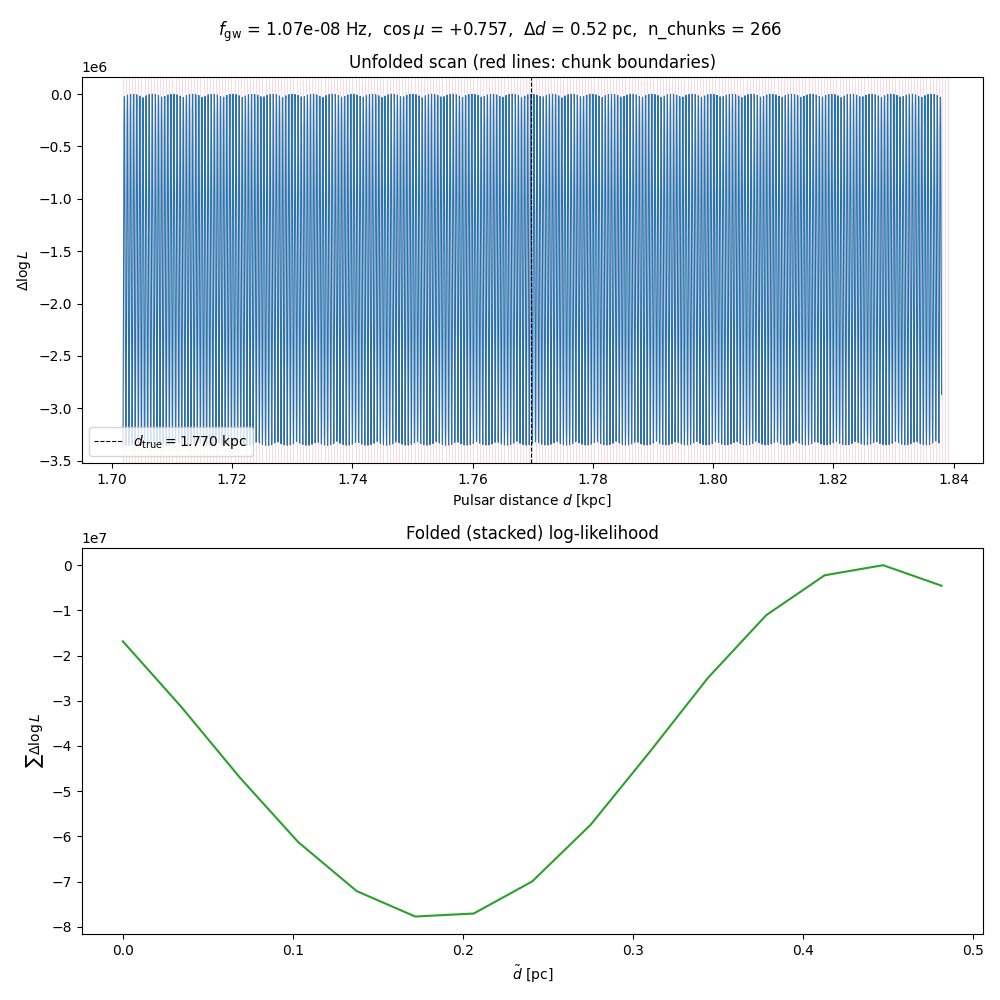

In [8]:
fig, (ax_un, ax_fold) = plt.subplots(2, 1, figsize=(10, 10))

ax_un.plot(d_grid_kpc, delta_logL, lw=0.8)
ax_un.axvline(d_true, color="k", ls="--", lw=0.8, label=f"$d_{{\\rm true}}={d_true:.3f}$ kpc")
for k in range(n_chunks + 1):
    ax_un.axvline(d_lo + k * delta_d_kpc, color="crimson", alpha=0.18, lw=0.6)
ax_un.set_xlabel("Pulsar distance $d$ [kpc]")
ax_un.set_ylabel(r"$\Delta\log L$")
ax_un.set_title("Unfolded scan (red lines: chunk boundaries)")
ax_un.legend(loc="lower left")

ax_fold.plot(d_tilde * 1e3, folded, color="C2")
ax_fold.set_xlabel(r"$\tilde d$ [pc]")
ax_fold.set_ylabel(r"$\sum \Delta\log L$")
ax_fold.set_title("Folded (stacked) log-likelihood")

fig.suptitle(
    f"$f_{{\\rm gw}}$ = {f_gw:.2e} Hz,  "
    f"$\\cos\\mu$ = {cos_mu:+.3f},  "
    f"$\\Delta d$ = {delta_d_kpc*1e3:.2f} pc,  "
    f"n_chunks = {n_chunks}"
)
fig.tight_layout()
plt.show()